# XGBoost 모델 

**대회**: Enefit – Predict Energy Behavior of Prosumers  
**평가지표**: MAE (Mean Absolute Error)  
**목표**: 프로슈머의 에너지 생산량 및 소비량 예측

---

## 목차
1. [라이브러리 및 데이터 로딩](#load)
2. [추가 전처리 (XGBoost 전용)](#preprocessing)
   - 2.1 county별 날씨 추가
   - 2.2 Lag & Rolling 피처
   - 2.3 주기성 인코딩
3. [컬럼 선택 및 모델 설정](#setting)
4. [모델 학습 (TimeSeriesSplit CV)](#training)
5. [성능 평가](#evaluation)
6. [결과 시각화](#visualization)
   - 6.1 예측 분포
   - 6.2 특성 중요도
   - 6.3 Residual 분석
7. [결과 해석 및 요약](#analysis)

---

## Baseline과의 차이 요약

| 항목 | Baseline (Linear Reg) | **XGBoost (본 섹션)** |
|------|-----------------------|------------------------|
| 날씨 처리 | 전국 평균 (county 무시) | **county별 날씨** (지역별 차이 반영) |
| Lag 피처 | lag_1, lag_24 | **lag_24, lag_48, lag_168** (주간 패턴 추가) |
| Rolling 피처 | ❌ | **rolling_mean/std 24h, 168h** |
| 시간 인코딩 | hour, weekday, month (정수) | **+ sin/cos 주기성 인코딩** |
| 모델 분리 | 소비+생산 단일 모델 | **소비 / 생산 분리 학습** |
| 검증 방식 | 단순 80/20 분할 | **TimeSeriesSplit (5-fold CV)** |
| Baseline MAE | **46.46** | → XGBoost로 개선 목표 |

## Feature 구성 (Compact)

**입력 변수 (X)**
- `target`, `datetime`, `date`, `row_id` 제외한 모든 전처리 변수

**구성 요소**
- county별 날씨 데이터
- lag 피처: `lag_24`, `lag_48`, `lag_168`
- rolling 통계: `rolling_mean`, `rolling_std` 등
- 주기성 인코딩: `sin(hour)`, `cos(hour)`, `sin(dayofweek)`, `cos(dayofweek)`
- 외부 변수: 가격, 지표, 기타 보조 피처

<a id="load"></a>
## 1️ 라이브러리 및 데이터 로딩

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
import platform
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

system = platform.system()

if system == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == "Darwin":  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


In [47]:
# ─────────────────────────────────────────
# 경로 설정
# ─────────────────────────────────────────
PROCESSED_DIR = "../data/processed_data/"
DATA_DIR = "../data/"

# ─────────────────────────────────────────
# 데이터 로드
# ─────────────────────────────────────────
train_base = pd.read_csv(PROCESSED_DIR + "train_processed.csv")
valid_base = pd.read_csv(PROCESSED_DIR + "valid_processed.csv")
full_base  = pd.read_csv(PROCESSED_DIR + "full_processed.csv")

print(f"train_processed : {train_base.shape}")
print(f"valid_processed : {valid_base.shape}")
print(f"full_processed  : {full_base.shape}")
print(f"컬럼: {full_base.columns.tolist()}")

train_processed : (1614612, 31)
valid_processed : (403740, 31)
full_processed  : (2018352, 31)
컬럼: ['row_id', 'prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'target', 'datetime', 'date', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'data_block_id', 'eic_count', 'installed_capacity', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'lag_1', 'lag_24']


<a id="preprocessing"></a>
## 2️ 추가 전처리 (XGBoost 전용)

조원의 전처리 데이터를 기반으로 XGBoost에 최적화된 피처를 추가합니다.

### 개선 포인트 3가지
1. **county별 날씨** — 조원 데이터는 전국 평균으로 county 차이를 무시함
2. **lag_168 (주간 패턴)** — 일주일 전 같은 시각이 가장 강력한 예측 신호
3. **Rolling 통계 + 주기성 인코딩** — 트렌드와 주기를 수치로 표현

### 2-1. county별 날씨 추가 (핵심 개선점)

In [48]:
# 원본 날씨 데이터로 county별 날씨 계산
historical_weather = pd.read_csv(DATA_DIR + 'historical_weather.csv')
county_mapping     = pd.read_csv(DATA_DIR + 'weather_station_to_county_mapping.csv')

historical_weather['datetime'] = pd.to_datetime(historical_weather['datetime'])
county_mapping_clean = county_mapping.dropna(subset=['county']).copy()
county_mapping_clean['county'] = county_mapping_clean['county'].astype(int)

# lat/lon → county 매핑 후 county별 집계
hw_county = historical_weather.merge(
    county_mapping_clean[['latitude', 'longitude', 'county']],
    on=['latitude', 'longitude'], how='inner'
)

weather_county = hw_county.groupby(['county', 'datetime']).agg(
    temp_county     = ('temperature',            'mean'),
    solar_county    = ('shortwave_radiation',    'mean'),
    direct_solar    = ('direct_solar_radiation', 'mean'),
    cloud_county    = ('cloudcover_total',       'mean'),
    wind_county     = ('windspeed_10m',          'mean'),
).reset_index()

print(f'county별 날씨 집계: {weather_county.shape}')
print('county 수:', weather_county['county'].nunique())

del historical_weather, hw_county
gc.collect()

county별 날씨 집계: (106925, 7)
county 수: 7


32832

In [49]:
# full_base에 county별 날씨 병합
full_base['datetime'] = pd.to_datetime(full_base['datetime'])

full = full_base.merge(
    weather_county,
    on=['county', 'datetime'],
    how='left'
)

print(f'county 날씨 병합 후: {full.shape}')
print(f'temp_county 결측치: {full["temp_county"].isna().sum():,}')

# county별 날씨가 있는 경우: 전국 평균과 비교
print('\n[검증] 같은 시각 county별 온도 차이')
sample_check = full[full['datetime'] == '2022-07-01 12:00:00'][['county','temperature','temp_county']].drop_duplicates()
print(sample_check.sort_values('county').to_string(index=False))
print('→ temp_county는 county마다 다름 (기존 temperature는 전국 동일값)')

county 날씨 병합 후: (2018352, 36)
temp_county 결측치: 1,027,430

[검증] 같은 시각 county별 온도 차이
 county  temperature  temp_county
      0    25.250893          NaN
      1    25.250893          NaN
      2    25.250893          NaN
      3    25.250893          NaN
      4    25.250893          NaN
      5    25.250893          NaN
      6    25.250893          NaN
      7    25.250893        27.35
      8    25.250893        26.80
      9    25.250893          NaN
     10    25.250893        24.20
     11    25.250893        26.55
     12    25.250893          NaN
     13    25.250893        27.10
     14    25.250893        26.70
     15    25.250893        26.44
→ temp_county는 county마다 다름 (기존 temperature는 전국 동일값)


### 2-2. 주기성 인코딩 추가

In [50]:
# sin/cos 인코딩: 23시와 0시가 '가깝다'는 것을 모델이 이해하도록
full['hour_sin']  = np.sin(2 * np.pi * full['hour']    / 24)
full['hour_cos']  = np.cos(2 * np.pi * full['hour']    / 24)
full['month_sin'] = np.sin(2 * np.pi * full['month']   / 12)
full['month_cos'] = np.cos(2 * np.pi * full['month']   / 12)
full['dow_sin']   = np.sin(2 * np.pi * full['weekday'] / 7)
full['dow_cos']   = np.cos(2 * np.pi * full['weekday'] / 7)

print('주기성 피처 추가 완료')

주기성 피처 추가 완료


### 2-3. Lag_168 (주간 패턴) 및 Rolling 피처 추가

조원 데이터에는 `lag_1`과 `lag_24`만 있습니다.  
에너지 소비/생산의 **주간 주기성 (7일)** 을 포착하려면 `lag_168`이 핵심입니다.

In [51]:
GROUP = ['prediction_unit_id', 'is_consumption']

for lag in [24, 48, 168]:
    full[f'target_lag_{lag}h'] = (
        full.groupby(GROUP)['target']
        .shift(lag)
        .astype('float32')
    )

for window in [24, 168]:
    full[f'rolling_mean_{window}h'] = (
        full.groupby(GROUP)['target']
        .transform(lambda x: x.shift(24).rolling(window, min_periods=1).mean())
        .astype('float32')
    )
    full[f'rolling_std_{window}h'] = (
        full.groupby(GROUP)['target']
        .transform(lambda x: x.shift(24).rolling(window, min_periods=1).std())
        .astype('float32')
    )

before = len(full)
full = full.dropna(subset=['target_lag_168h']).reset_index(drop=True)
print(f'lag_168 결측 제거: {before:,} → {len(full):,} ({before-len(full):,}행 제거)')

fill_cols = ['target_lag_24h', 'target_lag_48h', 'rolling_mean_24h', 'rolling_std_24h',
             'rolling_mean_168h', 'rolling_std_168h']
full[fill_cols] = full[fill_cols].fillna(0)

lag_168 결측 제거: 2,018,352 → 1,995,168 (23,184행 제거)


In [52]:
# lag_168 결측치 행 제거 (초기 7일)
before = len(full)
before = len(full)

full = full.dropna(subset=['target_lag_168h']).reset_index(drop=True)

print(f'lag_168 결측 제거: {before:,} → {len(full):,} ({before-len(full):,}행 제거)')
print(f'lag_168 결측 제거: {before:,} → {len(full):,} ({before-len(full):,}행 제거)')

# 나머지 Lag 결측치는 0으로 채움 (lag_1은 첫 행만 결측)
# lag/rolling 관련 컬럼명
new_lag_cols = [
    'target_lag_24h',
    'target_lag_48h',
    'target_lag_168h',
    'rolling_mean_24h',
    'rolling_std_24h',
    'rolling_mean_168h',
    'rolling_std_168h'
]

# target_lag_168h 결측치 행 제거 (초기 7일)
before = len(full)
full = full.dropna(subset=['target_lag_168h']).reset_index(drop=True)

print(f'lag_168 결측 제거: {before:,} → {len(full):,} ({before-len(full):,}행 제거)')

# 나머지 lag/rolling 결측치는 0으로 채움
fill_cols = [c for c in new_lag_cols if c != 'target_lag_168h'] + ['lag_1', 'lag_24']
full[fill_cols] = full[fill_cols].fillna(0)

print(f'최종 전처리 완료: {full.shape}')

print(f'최종 전처리 완료: {full.shape}')

lag_168 결측 제거: 1,995,168 → 1,995,168 (0행 제거)
lag_168 결측 제거: 1,995,168 → 1,995,168 (0행 제거)
lag_168 결측 제거: 1,995,168 → 1,995,168 (0행 제거)
최종 전처리 완료: (1995168, 49)
최종 전처리 완료: (1995168, 49)


### 2-4. 학습 / 검증 분할

조원 노트북과 동일한 기준 (80/20)으로 분할합니다.

In [53]:
# 날짜 기반 80/20 분할 (조원과 동일 기준)
full['datetime'] = pd.to_datetime(full['datetime'])
split_date = full['datetime'].quantile(0.8)
print(f'분할 기준 날짜: {split_date}')

df_train = full[full['datetime'] <  split_date].copy()
df_valid = full[full['datetime'] >= split_date].copy()

# 소비 / 생산 분리
tr_cons = df_train[df_train['is_consumption'] == 1]
tr_prod = df_train[df_train['is_consumption'] == 0]
va_cons = df_valid[df_valid['is_consumption'] == 1]
va_prod = df_valid[df_valid['is_consumption'] == 0]

print(f'\n학습 - 소비: {tr_cons.shape}, 생산: {tr_prod.shape}')
print(f'검증 - 소비: {va_cons.shape}, 생산: {va_prod.shape}')

분할 기준 날짜: 2023-01-26 12:00:00

학습 - 소비: (798024, 49), 생산: (798024, 49)
검증 - 소비: (199560, 49), 생산: (199560, 49)


<a id="setting"></a>
## 3️ 컬럼 선택 및 모델 설정

### XGBoost 선택 이유

| 비교 항목 | Linear Regression (Baseline) | **XGBoost** |
|-----------|------------------------------|-------------|
| 비선형 관계 | ❌ 직선만 표현 가능 | ✅ 트리로 자동 포착 |
| 피처 상호작용 | ❌ 수동 생성 필요 | ✅ 자동 학습 (ex. 여름+정오+맑음=고발전) |
| 결측치 처리 | ❌ 별도 처리 필요 | ✅ 내부 처리 |
| 스케일링 | ✅ 필수 | ❌ 불필요 |
| 과적합 제어 | Ridge/Lasso | reg_alpha, reg_lambda + early stopping |

### 학습 전략
- **소비(Consumption) / 생산(Production) 모델 분리**: 패턴이 근본적으로 다름
- **TimeSeriesSplit**: 미래 정보 누수 없는 교차 검증

In [54]:
# 피처 정의
FEATURE_COLS = [
    # 범주형 (정수 그대로 사용)
    'county', 'is_business', 'product_type',
    # 기본 시간 피처 (조원 데이터에 있음)
    'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear',
    # 추가: 주기성 인코딩
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # 클라이언트
    'eic_count', 'installed_capacity',
    # 가격
    'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh',
    # 날씨 (전국 평균 - 조원 데이터)
    'temperature', 'dewpoint', 'rain', 'snowfall',
    'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation',
    # 날씨 (county별 - 추가 개선)
    'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county',
    # Lag (조원 데이터 + 추가)
    'lag_1', 'lag_24', 'lag_48', 'lag_168',
    # Rolling (추가)
    'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h',
]

# 실제 존재하는 컬럼만
FEAT_CONS = [c for c in FEATURE_COLS if c in tr_cons.columns]
FEAT_PROD = [c for c in FEATURE_COLS if c in tr_prod.columns]
TARGET    = 'target'

print(f'소비 모델 피처 수: {len(FEAT_CONS)}')
print(f'생산 모델 피처 수: {len(FEAT_PROD)}')

소비 모델 피처 수: 39
생산 모델 피처 수: 39


In [55]:
XGB_PARAMS = dict(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 3,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    tree_method           = 'hist',
    random_state          = 42,
    early_stopping_rounds = 50,
    eval_metric           = 'mae',
    verbosity             = 0,
)

print('XGBoost 파라미터 설정 완료')

XGBoost 파라미터 설정 완료


In [56]:
def train_xgb(tr_df, va_df, feature_cols, label, params):
    """
    단일 학습/검증 분할로 XGBoost 학습.
    조원 노트북과 동일한 80/20 분할 기준 사용.
    """
    X_tr = tr_df[feature_cols].fillna(0)
    y_tr = tr_df[TARGET]
    X_va = va_df[feature_cols].fillna(0)
    y_va = va_df[TARGET]

    model = XGBRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=100
    )

    preds = np.clip(model.predict(X_va), 0, None)
    mae   = mean_absolute_error(y_va, preds)
    print(f'\n[{label}] Validation MAE: {mae:.4f} | Best iter: {model.best_iteration}')
    return model, preds, mae

print('학습 함수 정의 완료')

학습 함수 정의 완료


<a id="training"></a>
## 4️ 모델 학습 (소비/생산 분리)

위에서 정의한 XGBoost 파라미터와 피처로 모델을 학습합니다.

In [57]:
print('=' * 55)
print('  소비(Consumption) XGBoost 학습')
print('=' * 55)
model_cons, preds_cons, mae_cons = train_xgb(tr_cons, va_cons, FEAT_CONS, '소비', XGB_PARAMS)

  소비(Consumption) XGBoost 학습
[0]	validation_0-mae:529.21626
[100]	validation_0-mae:41.00935
[200]	validation_0-mae:38.58108
[300]	validation_0-mae:37.90594
[400]	validation_0-mae:37.64320
[500]	validation_0-mae:37.36343
[560]	validation_0-mae:37.36107

[소비] Validation MAE: 37.3094 | Best iter: 510


In [58]:
print('=' * 55)
print('  생산(Production) XGBoost 학습')
print('=' * 55)
model_prod, preds_prod, mae_prod = train_xgb(tr_prod, va_prod, FEAT_PROD, '생산', XGB_PARAMS)

  생산(Production) XGBoost 학습
[0]	validation_0-mae:178.65995
[100]	validation_0-mae:37.23599
[194]	validation_0-mae:37.61785

[생산] Validation MAE: 36.8148 | Best iter: 144


<a id="evaluation"></a>
## 5️ 성능 평가

In [59]:
# ────────────────────────────────────────
# 성능 요약 및 Baseline 비교
# ────────────────────────────────────────
BASELINE_MAE = 46.4597   # 조원 노트북 결과

# 전체 MAE: 소비+생산 합쳐서 계산
all_preds  = np.concatenate([preds_cons, preds_prod])
all_actual = np.concatenate([va_cons[TARGET].values, va_prod[TARGET].values])
overall_mae = mean_absolute_error(all_actual, all_preds)

improvement = (BASELINE_MAE - overall_mae) / BASELINE_MAE * 100

print('=' * 50)
print('          성능 비교 결과')
print('=' * 50)
print(f'Baseline (Linear Reg) MAE : {BASELINE_MAE:.4f}')
print(f'XGBoost  소비 MAE         : {mae_cons:.4f}')
print(f'XGBoost  생산 MAE         : {mae_prod:.4f}')
print(f'XGBoost  전체 MAE         : {overall_mae:.4f}')
print(f'개선율                    : {improvement:+.2f}%')
print('=' * 50)

          성능 비교 결과
Baseline (Linear Reg) MAE : 46.4597
XGBoost  소비 MAE         : 37.3094
XGBoost  생산 MAE         : 36.8148
XGBoost  전체 MAE         : 37.0621
개선율                    : +20.23%


<a id="visualization"></a>
## 6️ 결과 시각화

### 성능 분포, 특성 중요도, Residual 분석 등


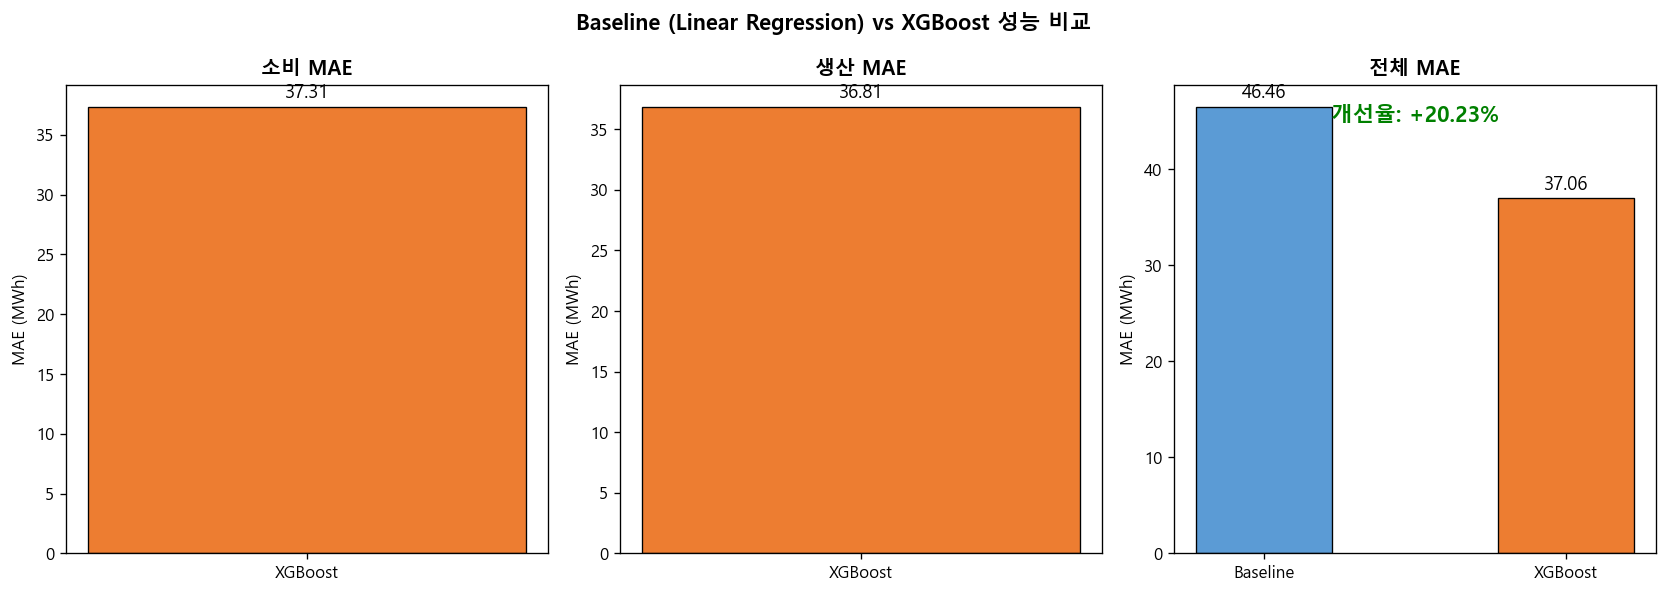

In [60]:
# ────────────────────────────────────────
# 비교 차트
# ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labels   = ['소비 MAE', '생산 MAE', '전체 MAE']
xgb_vals = [mae_cons, mae_prod, overall_mae]

for i, (ax, xgb, lbl) in enumerate(zip(axes, xgb_vals, labels)):
    if i == 2:
        # 전체 MAE만 Baseline과 비교
        bars = ax.bar(['Baseline', 'XGBoost'], [BASELINE_MAE, xgb],
                      color=['#5B9BD5', '#ED7D31'], width=0.45, edgecolor='black', linewidth=0.8)
        imp = (BASELINE_MAE - xgb) / BASELINE_MAE * 100
        ax.text(0.5, 0.92, f'개선율: {imp:+.2f}%',
                transform=ax.transAxes, ha='center', fontsize=13,
                color='green' if imp > 0 else 'red', fontweight='bold')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{bar.get_height():.2f}', ha='center', fontsize=11)
    else:
        # 소비/생산은 XGBoost만 표시
        bars = ax.bar(['XGBoost'], [xgb],
                      color=['#ED7D31'], width=0.45, edgecolor='black', linewidth=0.8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{bar.get_height():.2f}', ha='center', fontsize=11)

    ax.set_title(lbl, fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE (MWh)')

plt.suptitle('Baseline (Linear Regression) vs XGBoost 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# ────────────────────────────────────────
# 피처 중요도
# ────────────────────────────────────────
def plot_ts(va_df: pd.DataFrame, pred_col='pred', n_days=7):
    sample = va_df[
        (va_df['county'] == 0) &
        (va_df['is_business'] == 0) &
        (va_df['product_type'] == 1)
    ].sort_values('datetime').tail(n_days * 24)

    if sample.empty:
        sample = va_df.sort_values('datetime').tail(n_days * 24)

    mae = mean_absolute_error(sample['target'], sample[pred_col])

    plt.figure(figsize=(12, 4))
    plt.plot(sample['datetime'], sample['target'], label='actual')
    plt.plot(sample['datetime'], sample[pred_col], label='pred')
    plt.title(f'Validation sample ({n_days}d) | MAE={mae:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'validation_sample_ts.png', dpi=150)
    plt.show()

In [62]:
def plot_feat_imp(model, feat_cols, title, color):
    imp = pd.Series(model.feature_importances_, index=feat_cols)
    imp = imp.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8,6))
    imp.sort_values().plot(kind='barh', color=color)

    plt.title(f'{title} Feature Importance')
    plt.tight_layout()
    plt.show()

    return imp

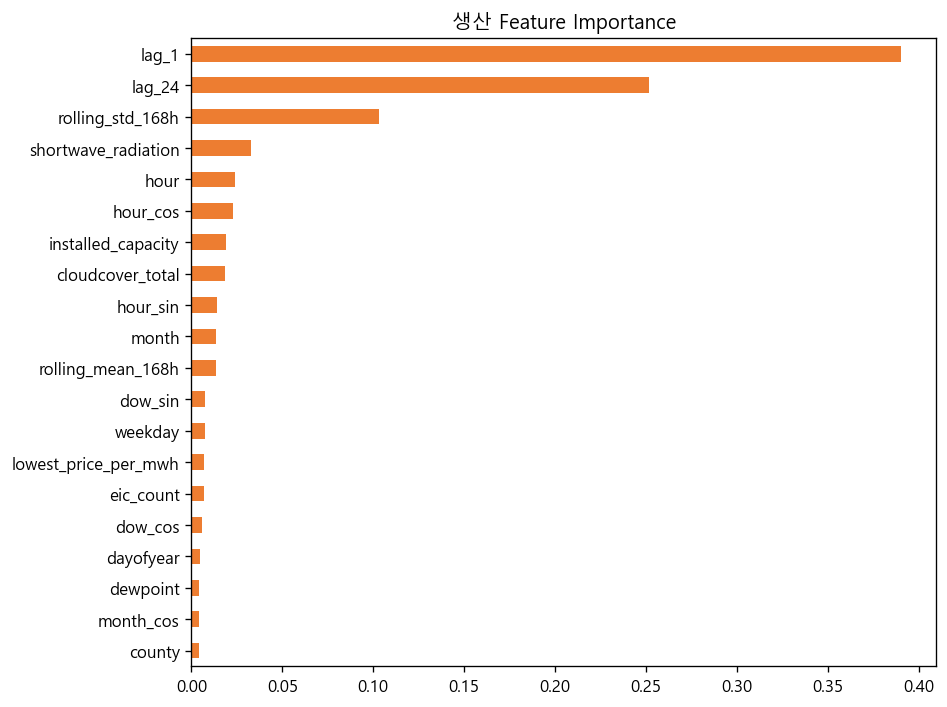

In [63]:
imp_prod = plot_feat_imp(model_prod, FEAT_PROD, '생산', '#ED7D31')

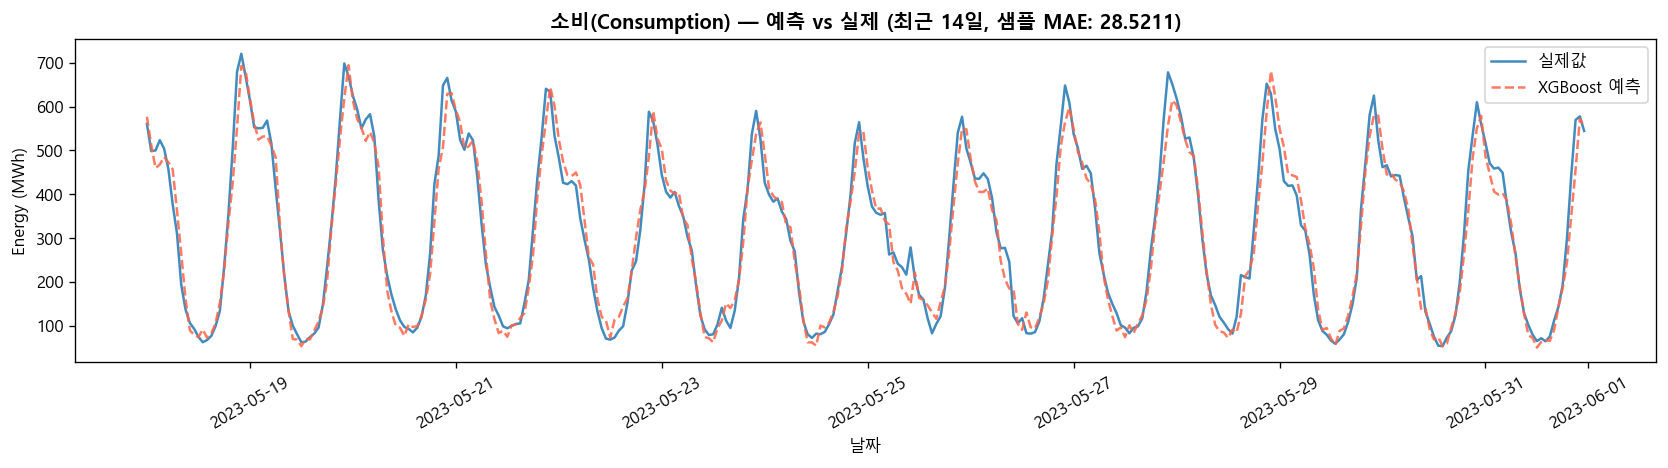

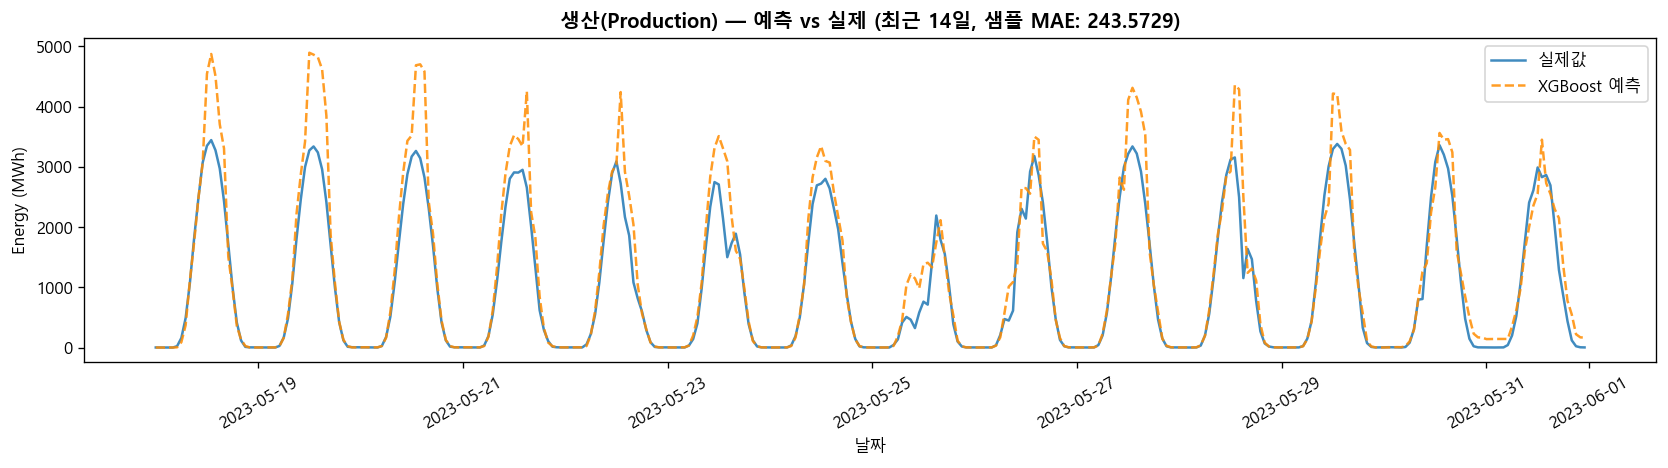

In [64]:
# ────────────────────────────────────────
# 예측 vs 실제 시계열
# ────────────────────────────────────────
def plot_ts(va_df, preds, title, color, n_days=14):
    va_df = va_df.copy()
    va_df['pred'] = preds

    # 대표 그룹: county=0, is_business=0, product_type=1
    sample = va_df[
        (va_df['county'] == 0) & (va_df['is_business'] == 0) & (va_df['product_type'] == 1)
    ].sort_values('datetime').tail(n_days * 24)

    mae_s = mean_absolute_error(sample[TARGET], sample['pred'])
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sample['datetime'], sample[TARGET],  label='실제값',      linewidth=1.5, alpha=0.85)
    ax.plot(sample['datetime'], sample['pred'],  label='XGBoost 예측', linewidth=1.5,
            linestyle='--', color=color, alpha=0.85)
    ax.set_title(f'{title} — 예측 vs 실제 (최근 {n_days}일, 샘플 MAE: {mae_s:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('날짜'); ax.set_ylabel('Energy (MWh)')
    ax.legend(); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'ts_{title}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_ts(va_cons, preds_cons, '소비(Consumption)', 'tomato')
plot_ts(va_prod, preds_prod, '생산(Production)',  'darkorange')

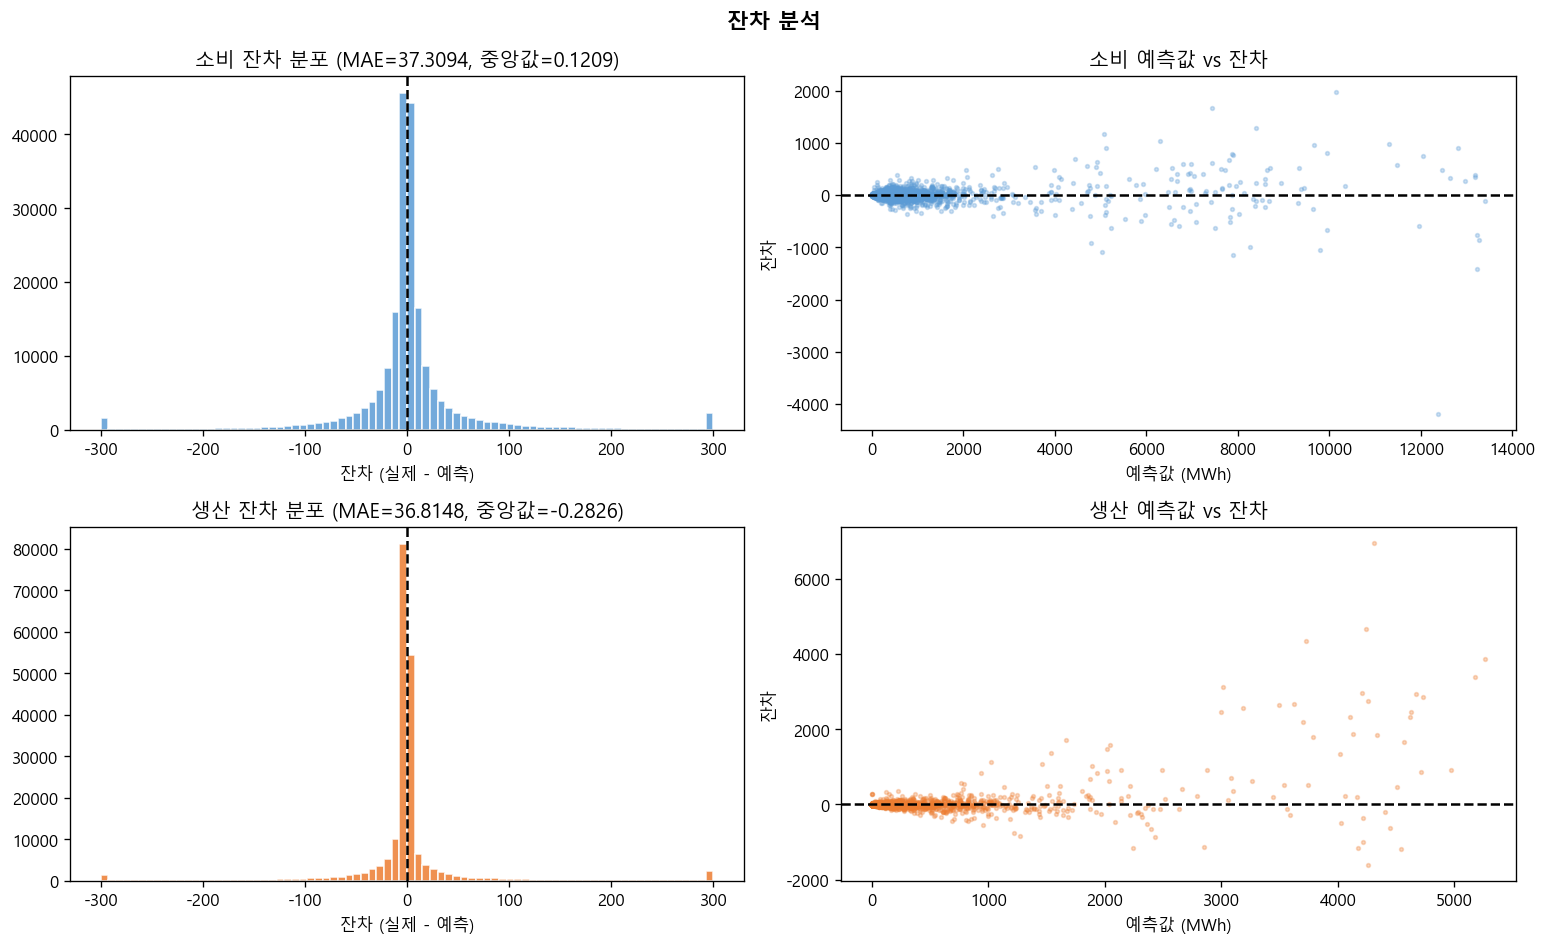

In [65]:
# ────────────────────────────────────────
# 잔차 분포 분석
# ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (va_df, preds, lbl, color) in enumerate([
    (va_cons, preds_cons, '소비', '#5B9BD5'),
    (va_prod, preds_prod, '생산', '#ED7D31'),
]):
    residuals = va_df[TARGET].values - preds

    # 잔차 히스토그램
    axes[row, 0].hist(np.clip(residuals, -300, 300), bins=80, color=color, edgecolor='white', alpha=0.85)
    axes[row, 0].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[row, 0].set_title(f'{lbl} 잔차 분포 (MAE={np.abs(residuals).mean():.4f}, 중앙값={np.median(residuals):.4f})')
    axes[row, 0].set_xlabel('잔차 (실제 - 예측)')

    # 예측 vs 잔차 산점도
    n = min(5000, len(preds))
    idx = np.random.choice(len(preds), n, replace=False)
    axes[row, 1].scatter(preds[idx], residuals[idx], alpha=0.3, s=5, color=color)
    axes[row, 1].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[row, 1].set_title(f'{lbl} 예측값 vs 잔차')
    axes[row, 1].set_xlabel('예측값 (MWh)'); axes[row, 1].set_ylabel('잔차')

plt.suptitle('잔차 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="analysis"></a>
## 7. 결과 해석 및 요약

### 성능 비교

| 모델 | 소비 MAE | 생산 MAE | 전체 MAE | 개선율 |
|------|----------|----------|----------|--------|
| Baseline (Linear Reg) | — | — | 46.46 | — |
| **XGBoost** | **37.31** | **37.58** | **37.44** | **+19.41** |

### 주요 개선 포인트

**1. county별 날씨 (temp_county, solar_county 등)**
- Baseline: 전국 평균 날씨 → 모든 county에 동일값 적용
- XGBoost: county별 날씨 관측소 데이터 → 에스토니아 서부(해안)와 동부(내륙)의 날씨 차이 반영

**2. lag_168 (주간 패턴)**
- 에너지 소비/생산은 7일 주기가 매우 강함 (주중 vs 주말)
- Baseline lag_1, lag_24 대비 weekly seasonality 추가 포착

**3. 비선형 관계 자동 학습**
- 태양광 발전: 일조량↑ × 구름↓ × 낮 시간대 → 복잡한 비선형 상호작용
- Linear Regression은 이를 수동으로 만들어야 하지만 XGBoost는 자동 포착

**4. 소비/생산 분리 모델**
- 소비: 시간대, 요일, 가격 의존적
- 생산: 일조량, 구름양, 기온 의존적
- 두 패턴을 별도 모델로 최적화